## 10.05 多头注意力

### 环境配置

In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import math
    import torch
    from torch import nn
    import torch_npu

warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor")

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

from src.pypto_ops import PyPTOBMM, PyPTOSoftmax, PyPTOLinear
from src.utils import sequence_mask, show_heatmaps

torch.manual_seed(0)


def masked_softmax_torch(X, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return nn.functional.softmax(X.reshape(shape), dim=-1)


def masked_softmax_pypto(X, valid_lens):
    if valid_lens is None:
        return PyPTOSoftmax.apply(X)
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return PyPTOSoftmax.apply(X.reshape(shape))


def transpose_qkv(X, num_heads):
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])


def transpose_output(X, num_heads):
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)


class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax_torch(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


class MultiHeadAttention(nn.Module):
    """多头注意力（支持保存每个头的注意力权重）"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        batch_size = queries.shape[0]
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)
        output = self.attention(queries, keys, values, valid_lens)
        # 保存每个头的注意力权重：(batch_size, num_heads, num_queries, num_keys)
        aw = self.attention.attention_weights
        self.head_weights = aw.reshape(batch_size, self.num_heads,
                                       aw.shape[1], aw.shape[2])
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

### 练习 10.5.1

**题目：** 分别可视化这个实验中的多个头的注意力权重。

**解答：** 多头注意力的权重形状为 `(batch_size*num_heads, 查询个数, 键的个数)`，其中同一 batch 的 `num_heads` 个头按顺序排列。把它 `reshape` 成 `(num_heads, 查询个数, 键的个数)` 即可逐头可视化（下面的 `MultiHeadAttention` 在 forward 中保存了 `head_weights`）。注意本例键与查询都为全 1 张量，且有效长度为 `[3, 2]`，因此每个头内权重分布相同（被掩蔽的位置为 0），但不同头的线性投影参数不同，仍可通过修改键来观察差异。

head_weights 形状： torch.Size([2, 5, 4, 6])


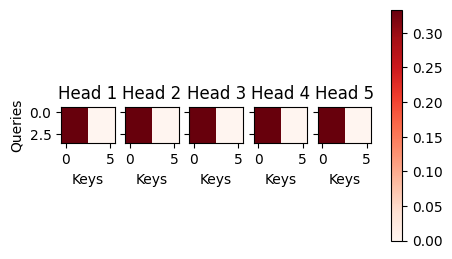

In [2]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,
                               num_hiddens, num_heads, 0.5)
attention.eval()
batch_size, num_queries = 2, 4
num_kvpairs, valid_lens = 6, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
attention(X, Y, Y, valid_lens)
# head_weights 形状：(batch_size, num_heads, num_queries, num_keys)
print('head_weights 形状：', attention.head_weights.shape)

# 可视化第 1 个样本的 5 个头（每行一个头）
w = attention.head_weights[0].unsqueeze(0)
show_heatmaps(w, xlabel='Keys', ylabel='Queries',
              titles=['Head %d' % i for i in range(1, num_heads + 1)],
              figsize=(5, 5))

使用 `PyPTO` 编程进行验证（PyPTOLinear + PyPTOBMM + PyPTOSoftmax）：

PyPTO head_weights 形状： torch.Size([2, 5, 4, 6])


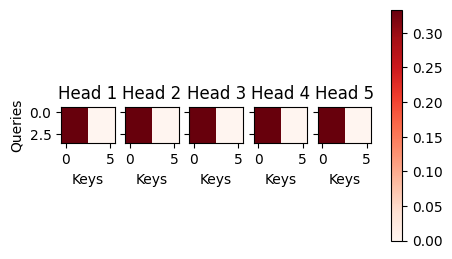

In [3]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class MultiHeadAttentionPypto(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttentionPypto(dropout)
        self.W_q = PyPTOLinear(query_size, num_hiddens, bias=bias)
        self.W_k = PyPTOLinear(key_size, num_hiddens, bias=bias)
        self.W_v = PyPTOLinear(value_size, num_hiddens, bias=bias)
        self.W_o = PyPTOLinear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        batch_size = queries.shape[0]
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)
        output = self.attention(queries, keys, values, valid_lens)
        # 保存每个头的注意力权重：(batch_size, num_heads, num_queries, num_keys)
        aw = self.attention.attention_weights
        self.head_weights = aw.reshape(batch_size, self.num_heads,
                                       aw.shape[1], aw.shape[2])
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)


class DotProductAttentionPypto(nn.Module):
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = PyPTOBMM.apply(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax_pypto(scores, valid_lens)
        return PyPTOBMM.apply(self.dropout(self.attention_weights), values)


attention_p = MultiHeadAttentionPypto(num_hiddens, num_hiddens, num_hiddens,
                                      num_hiddens, num_heads, 0.5).to(device)
attention_p.eval()
X_d, Y_d = X.to(device), Y.to(device)
valid_lens_d = valid_lens.to(device)
attention_p(X_d, Y_d, Y_d, valid_lens_d)
print('PyPTO head_weights 形状：', attention_p.head_weights.shape)
w_p = attention_p.head_weights[0].detach().cpu().unsqueeze(0)
show_heatmaps(w_p, xlabel='Keys', ylabel='Queries',
              titles=['Head %d' % i for i in range(1, num_heads + 1)],
              figsize=(5, 5))

### 练习 10.5.2

**题目：** 假设有一个完成训练的基于多头注意力的模型，现在希望修剪最不重要的注意力头以提高预测速度。如何设计实验来衡量注意力头的重要性呢？

**解答：** 常见的"头重要性"度量方法：

- **遮挡/消融实验（最直接）**：逐个（或组合）将某个头的输出置零（如把该头的注意力权重置为均匀分布、或直接截断该头分支），在验证集上测量指标（损失/BLEU/准确率）下降幅度，下降越多的头越重要；
- **梯度重要性**：计算损失对每个头参数的梯度范数（或 Fisher 信息），梯度越大说明该头对损失影响越大；
- **注意力熵**：头在训练集上的平均注意力熵越低（权重越集中、越"专注"），说明该头学到更有区分度的模式，通常更关键；
- **启发式**：与"随机初始化"对照——把一个头的权重重置为随机初始值，若模型性能几乎不变，则该头可安全剪除。

实验流程：按重要性排序 → 从最不重要的头开始逐个剪除 → 在验证集上跟踪性能曲线 → 在满足性能约束（如 BLEU 下降 &lt; 0.5）的前提下最大化剪除数量，从而获得推理速度提升。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)